<a href="https://colab.research.google.com/github/faheema2006/MLOPS/blob/main/KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
dataset = pd.read_csv('/content/clean_resume_dataset.csv')
print(dataset.head())

    ResumeID        Category              Name              Email  \
0  REAL_0001  Java Developer      Chad Griffin  contact@email.com   
1  REAL_0002  Java Developer    Melinda Thomas  contact@email.com   
2  REAL_0003  Java Developer  Shannon Mccarthy  contact@email.com   
3  REAL_0004  Java Developer  Christine Kelley  contact@email.com   
4  REAL_0005  Java Developer        Karen Holt  contact@email.com   

                                               Phone     Location  \
0  94105 555 4321000          10                 ...  City, State   
1  17994568777  2017 2018 20152016       3       ...  City, State   
2  9  555 4321000      94105   8                 ...  City, State   
3  9  555 4321000      94105   5                 ...  City, State   
4  100   10   4321000                            ...  City, State   

                                             Summary                   Skills  \
0  jessica claire montgomery street san francisco...  Python, SQL, Git, Linux   
1  jared

In [7]:
print(dataset.columns)

Index(['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary',
       'Skills', 'Experience', 'Education', 'Text', 'Source'],
      dtype='object')


In [8]:
dataset['Category'].unique()

array(['Java Developer', 'Python Developer', 'Data Science', 'DevOps',
       'SQL Developer', 'Database', 'Testing', 'Web Designing',
       'React Developer', 'DotNet Developer', 'ETL Developer',
       'Network Security Engineer', 'SAP Developer', 'Blockchain',
       'Business Analyst', 'Digital Media', 'Software Developer',
       'Full Stack Developer', 'Cloud Engineer',
       'Machine Learning Engineer', 'Frontend Developer',
       'Backend Developer', 'AI Engineer', 'Cybersecurity Analyst',
       'QA Engineer', 'Database Administrator', 'UI/UX Designer',
       'Site Reliability Engineer', 'Mobile Developer',
       'System Administrator', 'Technical Lead', 'Blockchain Developer',
       'Engineering Manager', 'Principal Engineer', 'Product Manager',
       'Technical Writer'], dtype=object)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
tfidf = TfidfVectorizer(max_features=300)

In [11]:
X = tfidf.fit_transform(dataset['Text']).toarray()

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()
y = encoder.fit_transform(dataset['Category'])

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

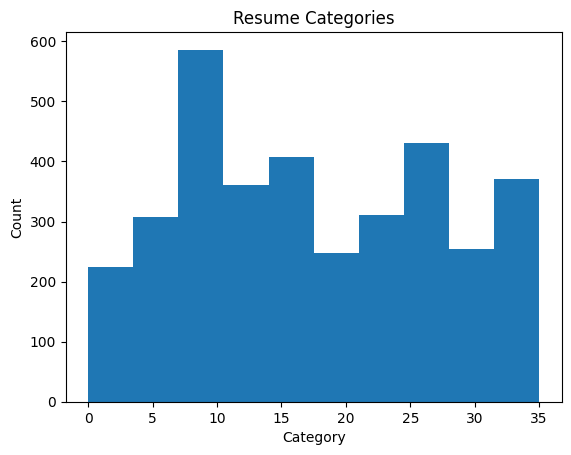

In [15]:
plt.hist(y)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Resume Categories')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [18]:
len(X_train)

2800

In [19]:
len(X_test)

700

In [1]:
from sklearn.neighbors import KNeighborsClassifier

In [2]:
knn = KNeighborsClassifier(n_neighbors=10)

In [20]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [21]:
knn.score(X_test,y_test)

0.8185714285714286

In [22]:
sample_resume = ["""Python SQL Machine Learning Deep Learning NLP Data Analysis"""]

In [23]:
sample_vector = tfidf.transform(sample_resume).toarray()

In [24]:
prediction = knn.predict(sample_vector)

In [25]:
predicted_category = encoder.inverse_transform(prediction)
print(predicted_category)

['Data Science']


In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test,y_pred)

In [28]:
print(cm)

[[12  0  0 ...  0  0  0]
 [ 0 14  0 ...  0  0  0]
 [ 0  0  3 ...  0  0  1]
 ...
 [ 0  0  0 ... 31  0  0]
 [ 0  0  0 ...  0 10  0]
 [ 0  0  0 ...  2  0 22]]


In [29]:
import seaborn as sn

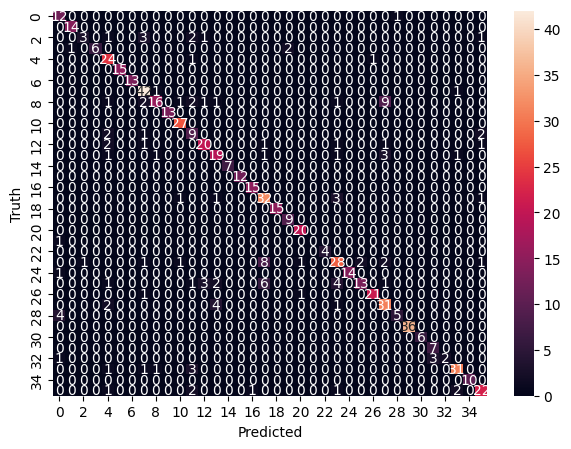

In [30]:
plt.figure(figsize=(7,5))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [31]:
from sklearn.metrics import classification_report

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.63      0.92      0.75        13
           1       0.93      1.00      0.97        14
           2       0.75      0.27      0.40        11
           3       1.00      0.67      0.80         9
           4       0.67      0.92      0.77        26
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        13
           7       0.81      0.95      0.88        44
           8       0.84      0.47      0.60        34
           9       1.00      1.00      1.00        13
          10       0.90      1.00      0.95        27
          11       0.45      0.64      0.53        14
          12       0.80      0.74      0.77        27
          13       0.70      0.70      0.70        27
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.00        12
          16       0.94      1.00      0.97        15
          17       0.67    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
